# Experiment 1 - MCSDCA vs AdamW as a full-model LeWM PushT predictor optimizer

`src/run_experiment1.py` runs, for **one PushT data fraction**, the whole pipeline
end to end:

1. **sanity** - odLD + udLD take a few steps and stay finite
2. **tune odLD** - coarse grid over `(eta, epsilon/eta ratio, beta0)` x >=2 seeds, ranked on the seed mean
3. **tune udLD** - grid over `delta`, inheriting `epsilon` / `beta0` from the odLD winner
4. **tune AdamW** - grid over `(lr, weight_decay)`
5. **evaluate** - all three optimizers at their winning config, N seeds, one **fixed backprop budget** (the same at every data fraction)

All five LeWM modules (`encoder`, `projector`, `action_encoder`, `predictor`,
`pred_proj`) are trained jointly from scratch on `prediction MSE + sigreg_weight * SIGReg`.
Every optimizer gets the same initial weights, the same batch stream, and the same
backprop budget, so results are compared on the `backprop_calls` axis - one MCSDCA
outer step performs several backward passes.

Each data fraction lives in `outputs/outputs/experiment1/data<pct>/`:

| file | contents |
| --- | --- |
| `winners.json` | tuned hyper-parameters per optimizer + the tune settings |
| `comparison.csv` | one row per (optimizer, seed) at the fixed eval budget |
| `comparison_agg.csv` | the same, aggregated to mean / std over seeds |
| `seed<n>/metrics.csv` | per-eval training trace for that seed |
| `seed<n>/run.json` | args + profile + resolved MCSDCA config + final metrics |
| `sweep_*/sweep_summary.csv` | every tuning grid point |

Set `FRACTION` in the config cell to focus the per-run views on one data fraction;
the data-scaling cell always uses every fraction found.


In [1]:
from __future__ import annotations

import csv
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src" / "run_experiment1.py").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Cannot find repository root.")

# run_experiment1.py writes to outputs/experiment1/; results were synced here under
# outputs/outputs/experiment1/. Take whichever exists (prefer the synced copy).
EXPERIMENT1_ROOT = next(
    (p for p in (ROOT / "outputs" / "outputs" / "experiment1", ROOT / "outputs" / "experiment1") if p.exists()),
    ROOT / "outputs" / "experiment1",
)


def read_json(path: Path):
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def read_csv(path: Path):
    with path.open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))


def num(row, key):
    try:
        return float(row.get(key, ""))
    except (TypeError, ValueError):
        return None


def fmt(value):
    if value in (None, ""):
        return ""
    try:
        x = float(value)
    except (TypeError, ValueError):
        return str(value)
    if x == int(x) and abs(x) < 1e15:
        return str(int(x))
    return f"{x:.3e}" if abs(x) >= 1000 or abs(x) < 1e-3 else f"{x:.6f}"


def table(rows, columns):
    head = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(fmt(r.get(c, "")) for c in columns) + " |" for r in rows]
    return "\n".join([head, sep, *body])


def tag_to_percent(tag: str) -> float:
    """data0p01 -> 0.01, data1 -> 1.0, data10 -> 10.0"""
    return float(tag.replace("data", "", 1).replace("p", "."))


def is_fraction_dir(path: Path) -> bool:
    return path.is_dir() and path.name.startswith("data") and (path / "comparison.csv").exists()


fraction_dirs = sorted(
    (p for p in EXPERIMENT1_ROOT.iterdir() if is_fraction_dir(p)) if EXPERIMENT1_ROOT.exists() else [],
    key=lambda p: tag_to_percent(p.name),
)
if not fraction_dirs:
    raise FileNotFoundError(f"No data<pct>/comparison.csv under {EXPERIMENT1_ROOT}. Run src/run_experiment1.py.")

FRACTIONS = {p.name: p for p in fraction_dirs}
display(Markdown(
    f"Experiment 1 root: `{EXPERIMENT1_ROOT}`\n\n"
    "Data fractions found: " + ", ".join(f"`{t}` ({tag_to_percent(t):g}%)" for t in FRACTIONS)
))


Experiment 1 root: `D:\DCA\MCSDCA\outputs\outputs\experiment1`

Data fractions found: `data0p01` (0.01%), `data1` (1%), `data10` (10%)

In [2]:
# Focus the per-run views (config, tables, curves, sampler) on one data fraction.
# Set to a key of FRACTIONS (e.g. "data1", "data10") or leave None for the largest.
FRACTION = None

ORDER = ["AdamW", "MCSDCA-odLD", "MCSDCA-udLD"]


def load_fraction(path: Path) -> dict:
    seeds = sorted(p for p in path.glob("seed*") if (p / "run.json").exists())
    winners_path = path / "winners.json"
    agg_path = path / "comparison_agg.csv"
    return {
        "tag": path.name,
        "percent": tag_to_percent(path.name),
        "path": path,
        "comparison": read_csv(path / "comparison.csv"),
        "agg": read_csv(agg_path) if agg_path.exists() else [],
        "winners": read_json(winners_path) if winners_path.exists() else None,
        "seed_dirs": seeds,
        "run": read_json(seeds[0] / "run.json") if seeds else None,
    }


DATA = {tag: load_fraction(path) for tag, path in FRACTIONS.items()}

focus_tag = FRACTION or max(FRACTIONS, key=tag_to_percent)
if focus_tag not in DATA:
    raise KeyError(f"FRACTION={focus_tag!r} not in {list(DATA)}")
focus = DATA[focus_tag]

run = focus["run"] or {}
n_seeds = len({r["seed"] for r in focus["comparison"]})
display(Markdown(
    f"**Focus fraction:** `{focus_tag}` ({focus['percent']:g}% of PushT train)  \n"
    f"**Optimizers:** {', '.join(ORDER)}  \n"
    f"**Eval budget:** {run.get('budget')} backprop calls "
    f"(~{run.get('epochs_equivalent', 0):.1f} epochs-equiv over {run.get('train_windows')} train windows)  \n"
    f"**Eval seeds:** {n_seeds}  \n"
    f"**Flow-test mode:** {focus['winners'].get('flow_test') if focus['winners'] else 'n/a'}"
))


**Focus fraction:** `data10` (10% of PushT train)  
**Optimizers:** AdamW, MCSDCA-odLD, MCSDCA-udLD  
**Eval budget:** 8000 backprop calls (~2.9 epochs-equiv over 178282 train windows)  
**Eval seeds:** 3  
**Flow-test mode:** n/a

In [3]:
args = run.get("args", {})
profile = run.get("profile", {})
mcsdca = run.get("mcsdca_config", {})
cache = run.get("window_cache", {})

config_rows = [
    {"key": "data fraction", "value": args.get("data_fraction")},
    {"key": "profile", "value": profile.get("name")},
    {"key": "train / val windows", "value": f"{run.get('train_windows')} / {run.get('val_windows')}"},
    {"key": "backprop budget", "value": run.get("budget")},
    {"key": "steps / epoch", "value": run.get("steps_per_epoch")},
    {"key": "epochs equivalent", "value": run.get("epochs_equivalent")},
    {"key": "batch size", "value": args.get("batch_size")},
    {"key": "precision", "value": args.get("precision")},
    {"key": "SIGReg projections", "value": args.get("sigreg_num_proj")},
    {"key": "objective", "value": f"pred_mse + {args.get('sigreg_weight')} * SIGReg"},
    {"key": "device", "value": run.get("device")},
    {"key": "window cache", "value": cache.get("reason")},
]
display(Markdown(f"### Run configuration - `{focus_tag}`\n\n" + table(config_rows, ["key", "value"])))

if focus["winners"]:
    w = focus["winners"]
    win_rows = [{"optimizer": k, "winning config": ", ".join(f"{kk}={vv:g}" for kk, vv in v.items())}
                for k, v in w["winners"].items()]
    display(Markdown(
        f"### Tuned winners - `{focus_tag}`\n\n"
        f"tune seeds {w.get('tune_seeds')}, tune budget {w.get('tune_budget')} backprop / point\n\n"
        + table(win_rows, ["optimizer", "winning config"])
    ))
else:
    display(Markdown(f"_No `winners.json` for `{focus_tag}` (evaluated with reused winners)._"))

mcsdca_rows = [{"parameter": k, "value": v} for k, v in mcsdca.items()]
display(Markdown("### Resolved MCSDCA config\n\n" + table(mcsdca_rows, ["parameter", "value"])))


### Run configuration - `data10`

| key | value |
| --- | --- |
| data fraction | 0.100000 |
| profile | small |
| train / val windows | 178282 / 24228 |
| backprop budget | 8000 |
| steps / epoch | 2786 |
| epochs equivalent | 2.871500 |
| batch size | 64 |
| precision | bf16 |
| SIGReg projections | 512 |
| objective | pred_mse + 0.09 * SIGReg |
| device | cuda |
| window cache | CPU-RAM-resident (~93.5 GB <= 555.8 GB cap, 926 GB free) |

_No `winners.json` for `data10` (evaluated with reused winners)._

### Resolved MCSDCA config

| parameter | value |
| --- | --- |
| langevin_steps | 5 |
| langevin_steps_power | 0.100000 |
| max_langevin_steps | 8 |
| burn_in | 2 |
| local_entropy_time | 10000 |
| gamma | 1.000e-05 |
| gamma_power | 0.100000 |
| beta0 | 0.500000 |
| epsilon | 3.000e-09 |
| od_eta | 0.003000 |
| ud_delta | 0.030000 |
| max_grad_norm | 1 |

In [4]:
per_seed_cols = ["optimizer", "seed", "backprop_calls", "val_mse", "train_mse", "train_val_gap",
                 "rollout_mse_1", "rollout_mse_3", "rollout_mse_5", "latent_norm_drift",
                 "pred_latent_variance", "status"]
agg_cols = ["optimizer", "n_seeds_ok", "val_mse_mean", "val_mse_std", "train_mse_mean",
            "train_val_gap_mean", "rollout_mse_1_mean", "rollout_mse_3_mean", "rollout_mse_5_mean"]


def opt_key(row):
    return ORDER.index(row["optimizer"]) if row["optimizer"] in ORDER else 99


rows = sorted(focus["comparison"], key=lambda r: (opt_key(r), r.get("seed", "")))
display(Markdown(f"### Per-seed comparison at the fixed budget - `{focus_tag}`\n\n"
                 + table(rows, per_seed_cols)))

agg = sorted(focus["agg"], key=opt_key)
display(Markdown(f"### Aggregated over {n_seeds} seed(s) (mean / std) - `{focus_tag}`\n\n"
                 + table(agg, agg_cols)))


### Per-seed comparison at the fixed budget - `data10`

| optimizer | seed | backprop_calls | val_mse | train_mse | train_val_gap | rollout_mse_1 | rollout_mse_3 | rollout_mse_5 | latent_norm_drift | pred_latent_variance | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| AdamW | 3072 | 8000 | 0.027688 | 0.025253 | 0.002435 | 0.026071 | 0.067689 | 0.119868 | -0.461486 | 0.837110 | ok |
| AdamW | 3073 | 8000 | 0.029949 | 0.025169 | 0.004781 | 0.030704 | 0.068401 | 0.112544 | -0.550197 | 0.779719 | ok |
| AdamW | 3074 | 8000 | 0.032622 | 0.029907 | 0.002716 | 0.029449 | 0.072176 | 0.130452 | -0.623159 | 0.794672 | ok |
| MCSDCA-odLD | 3072 | 8001 | 0.608400 | 0.581391 | 0.027009 | 0.601284 | 0.706750 | 0.733996 | -9.071900 | 0.031574 | ok |
| MCSDCA-odLD | 3073 | 8001 | 0.610645 | 0.608039 | 0.002606 | 0.602314 | 0.663027 | 0.680492 | -8.289368 | 0.020263 | ok |
| MCSDCA-odLD | 3074 | 8001 | 0.587644 | 0.563954 | 0.023689 | 0.583026 | 0.618849 | 0.624558 | -7.686625 | 0.027274 | ok |
| MCSDCA-udLD | 3072 | 8001 | 0.770252 | 0.714842 | 0.055410 | 0.756947 | 0.871579 | 0.883145 | -9.635419 | 0.025877 | ok |
| MCSDCA-udLD | 3073 | 8001 | 0.636547 | 0.672621 | -0.036075 | 0.662556 | 0.680183 | 0.673556 | -7.252997 | 0.023924 | ok |
| MCSDCA-udLD | 3074 | 8001 | 0.637884 | 0.603422 | 0.034462 | 0.643946 | 0.662106 | 0.651523 | -6.762781 | 0.026344 | ok |

### Aggregated over 3 seed(s) (mean / std) - `data10`

| optimizer | n_seeds_ok | val_mse_mean | val_mse_std | train_mse_mean | train_val_gap_mean | rollout_mse_1_mean | rollout_mse_3_mean | rollout_mse_5_mean |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| AdamW | 3 | 0.030087 | 0.002017 | 0.026776 | 0.003310 | 0.028741 | 0.069422 | 0.120955 |
| MCSDCA-odLD | 3 | 0.602230 | 0.010355 | 0.584461 | 0.017768 | 0.595541 | 0.662876 | 0.679682 |
| MCSDCA-udLD | 3 | 0.681561 | 0.062716 | 0.663628 | 0.017933 | 0.687817 | 0.737956 | 0.736075 |

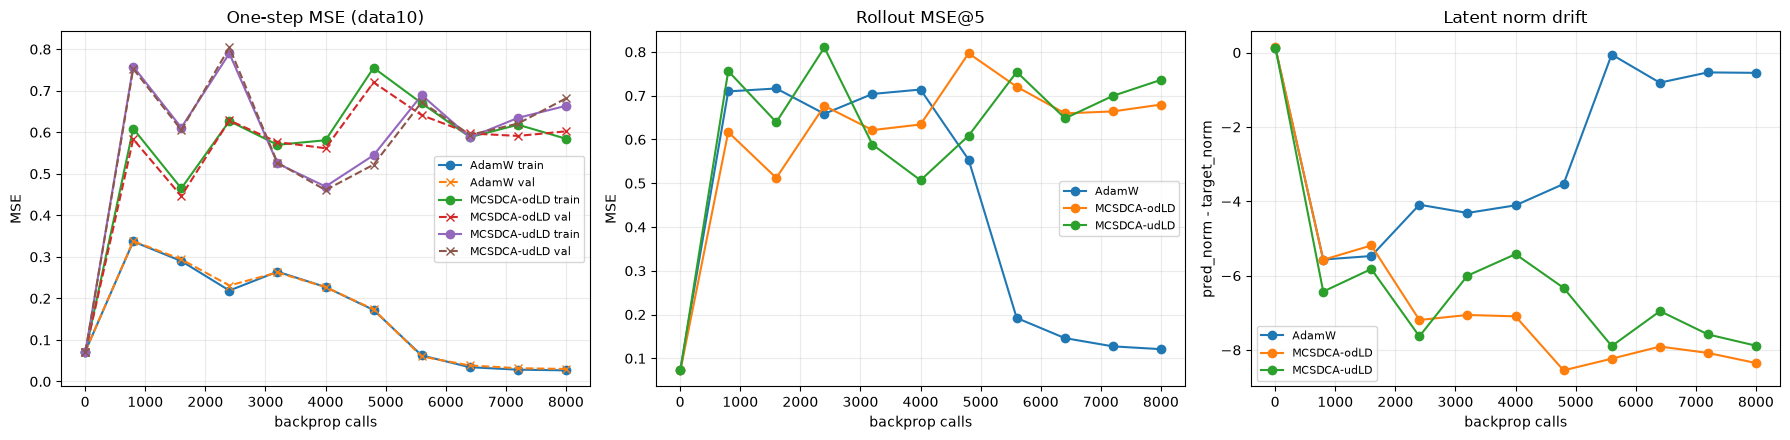

In [5]:
# Training curves for the focus fraction: mean over seeds by eval index
# (eval_interval is identical per seed, so row i is the same backprop step).
traces = defaultdict(list)  # optimizer -> list of per-seed sorted row-lists
for seed_dir in focus["seed_dirs"]:
    by_opt = defaultdict(list)
    for r in read_csv(seed_dir / "metrics.csv"):
        by_opt[r["optimizer"]].append(r)
    for opt, rs in by_opt.items():
        rs.sort(key=lambda r: num(r, "backprop_calls") or 0)
        traces[opt].append(rs)


def mean_curve(runs, ref, key):
    out = []
    for i in range(len(ref)):
        vals = [num(rs[i], key) for rs in runs if i < len(rs) and num(rs[i], key) is not None]
        out.append(sum(vals) / len(vals) if vals else float("nan"))
    return out


fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for opt in ORDER:
    runs = traces.get(opt, [])
    if not runs:
        continue
    ref = min(runs, key=len)
    x = [num(r, "backprop_calls") for r in ref]
    axes[0].plot(x, mean_curve(runs, ref, "train_mse"), marker="o", label=f"{opt} train")
    axes[0].plot(x, mean_curve(runs, ref, "val_mse"), marker="x", linestyle="--", label=f"{opt} val")
    axes[1].plot(x, mean_curve(runs, ref, "rollout_mse_5"), marker="o", label=opt)
    axes[2].plot(x, mean_curve(runs, ref, "latent_norm_drift"), marker="o", label=opt)

for ax, title, ylabel in zip(
    axes,
    [f"One-step MSE ({focus_tag})", "Rollout MSE@5", "Latent norm drift"],
    ["MSE", "MSE", "pred_norm - target_norm"],
):
    ax.set_title(title)
    ax.set_xlabel("backprop calls")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


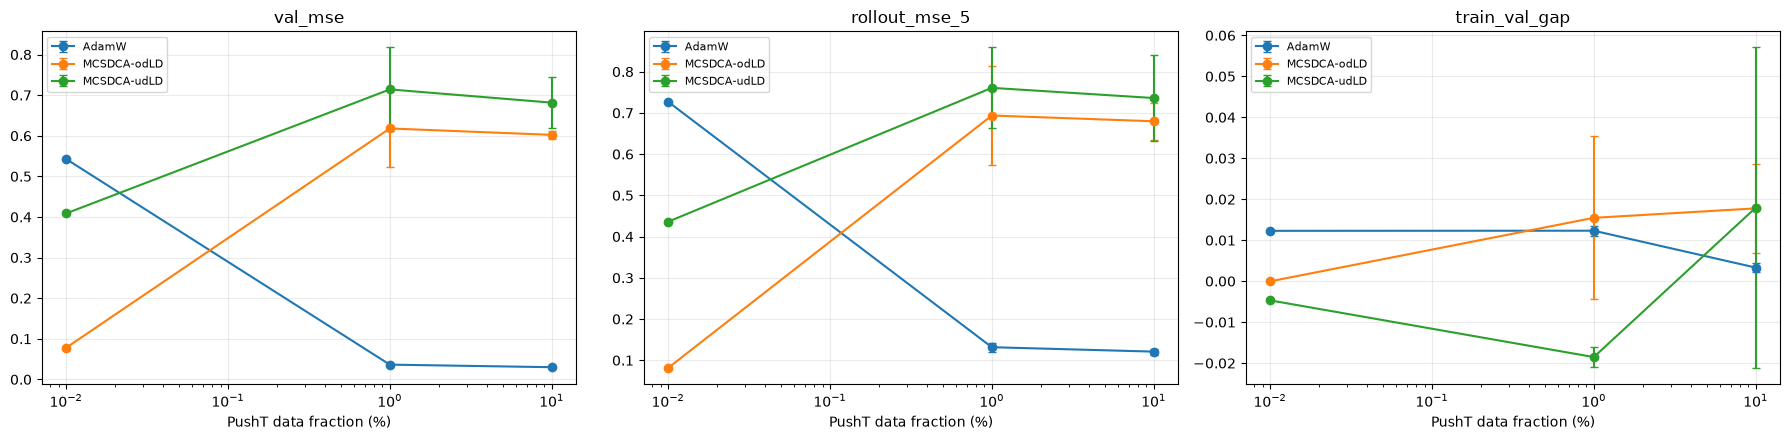

### Fixed-budget eval across data fractions

| data_% | optimizer | n_seeds | val_mse | rollout5 | train_val_gap |
| --- | --- | --- | --- | --- | --- |
| 0.010000 | AdamW | 1 | 0.542948 | 0.727251 | 0.012284 |
| 0.010000 | MCSDCA-odLD | 1 | 0.077743 | 0.081181 | -5.352e-05 |
| 0.010000 | MCSDCA-udLD | 1 | 0.408662 | 0.435965 | -0.004682 |
| 1 | AdamW | 3 | 0.036406 | 0.131663 | 0.012315 |
| 1 | MCSDCA-odLD | 3 | 0.617986 | 0.693645 | 0.015457 |
| 1 | MCSDCA-udLD | 3 | 0.714147 | 0.760744 | -0.018534 |
| 10 | AdamW | 3 | 0.030087 | 0.120955 | 0.003310 |
| 10 | MCSDCA-odLD | 3 | 0.602230 | 0.679682 | 0.017768 |
| 10 | MCSDCA-udLD | 3 | 0.681561 | 0.736075 | 0.017933 |

In [6]:
# Data-scaling view: fixed-budget eval metric vs PushT data fraction, one line per optimizer.
# Does MCSDCA's advantage grow when data is scarce (fewer windows = more overfitting pressure)?
metrics_to_plot = ["val_mse", "rollout_mse_5", "train_val_gap"]
tags = list(DATA)
percents = [DATA[t]["percent"] for t in tags]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6 * len(metrics_to_plot), 4.5))
for ax, metric in zip(axes, metrics_to_plot):
    for opt in ORDER:
        means, stds = [], []
        for t in tags:
            hit = next((r for r in DATA[t]["agg"] if r["optimizer"] == opt), None)
            m = num(hit, f"{metric}_mean") if hit else None
            s = num(hit, f"{metric}_std") if hit else None
            means.append(m if m is not None else float("nan"))
            stds.append(s if s is not None else 0.0)
        ax.errorbar(percents, means, yerr=stds, marker="o", capsize=3, label=opt)
    ax.set_title(metric)
    ax.set_xlabel("PushT data fraction (%)")
    ax.set_xscale("log")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

scale_rows = []
for t in tags:
    for opt in ORDER:
        hit = next((r for r in DATA[t]["agg"] if r["optimizer"] == opt), None)
        if not hit:
            continue
        scale_rows.append({
            "data_%": DATA[t]["percent"], "optimizer": opt,
            "n_seeds": hit.get("n_seeds_ok"),
            "val_mse": hit.get("val_mse_mean"), "rollout5": hit.get("rollout_mse_5_mean"),
            "train_val_gap": hit.get("train_val_gap_mean"),
        })
display(Markdown("### Fixed-budget eval across data fractions\n\n"
                 + table(scale_rows, ["data_%", "optimizer", "n_seeds", "val_mse", "rollout5", "train_val_gap"])))


In [7]:
# MCSDCA sampler trace for the focus fraction: the growing Markov chain, retained
# samples, gamma_k noise schedule, and inner sampler loss over training.
sampler_cols = ["optimizer", "seed", "backprop_calls", "outer_step", "markov_chain_length",
                "retained_samples", "gamma_k", "sampler_loss", "train_mse", "val_mse", "rollout_mse_5"]
tail = []
for seed_dir in focus["seed_dirs"]:
    by_opt = defaultdict(list)
    for r in read_csv(seed_dir / "metrics.csv"):
        by_opt[r["optimizer"]].append(dict(r, seed=seed_dir.name))
    for opt in ("MCSDCA-odLD", "MCSDCA-udLD"):
        rs = sorted(by_opt.get(opt, []), key=lambda r: num(r, "backprop_calls") or 0)
        tail.extend(rs[-3:])
display(Markdown(f"### MCSDCA sampler trace (last 3 evals per seed) - `{focus_tag}`\n\n"
                 + table(tail, sampler_cols)))


### MCSDCA sampler trace (last 3 evals per seed) - `data10`

| optimizer | seed | backprop_calls | outer_step | markov_chain_length | retained_samples | gamma_k | sampler_loss | train_mse | val_mse | rollout_mse_5 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| MCSDCA-odLD | seed3072 | 6405 | 1238 | 7 | 5 | 2.038e-04 | 1.005296 | 0.634938 | 0.659746 | 0.760717 |
| MCSDCA-odLD | seed3072 | 7203 | 1371 | 7 | 5 | 2.059e-04 | 0.998618 | 0.523514 | 0.523058 | 0.646506 |
| MCSDCA-odLD | seed3072 | 8001 | 1504 | 7 | 5 | 2.078e-04 | 0.964108 | 0.581391 | 0.608400 | 0.733996 |
| MCSDCA-udLD | seed3072 | 6405 | 1238 | 7 | 5 | 2.038e-04 | 1.117518 | 0.801861 | 0.816761 | 0.899515 |
| MCSDCA-udLD | seed3072 | 7203 | 1371 | 7 | 5 | 2.059e-04 | 1.102880 | 0.540143 | 0.484589 | 0.644622 |
| MCSDCA-udLD | seed3072 | 8001 | 1504 | 7 | 5 | 2.078e-04 | 1.074913 | 0.714842 | 0.770252 | 0.883145 |
| MCSDCA-odLD | seed3073 | 6405 | 1238 | 7 | 5 | 2.038e-04 | 1.052932 | 0.559225 | 0.559833 | 0.607622 |
| MCSDCA-odLD | seed3073 | 7203 | 1371 | 7 | 5 | 2.059e-04 | 1.022402 | 0.664115 | 0.602170 | 0.649818 |
| MCSDCA-odLD | seed3073 | 8001 | 1504 | 7 | 5 | 2.078e-04 | 0.991795 | 0.608039 | 0.610645 | 0.680492 |
| MCSDCA-udLD | seed3073 | 6405 | 1238 | 7 | 5 | 2.038e-04 | 1.170833 | 0.519975 | 0.505841 | 0.533008 |
| MCSDCA-udLD | seed3073 | 7203 | 1371 | 7 | 5 | 2.059e-04 | 1.164891 | 0.682689 | 0.643201 | 0.698318 |
| MCSDCA-udLD | seed3073 | 8001 | 1504 | 7 | 5 | 2.078e-04 | 1.172075 | 0.672621 | 0.636547 | 0.673556 |
| MCSDCA-odLD | seed3074 | 6405 | 1238 | 7 | 5 | 2.038e-04 | 1.076848 | 0.570649 | 0.572001 | 0.610424 |
| MCSDCA-odLD | seed3074 | 7203 | 1371 | 7 | 5 | 2.059e-04 | 1.072482 | 0.666874 | 0.648427 | 0.695701 |
| MCSDCA-odLD | seed3074 | 8001 | 1504 | 7 | 5 | 2.078e-04 | 1.032045 | 0.563954 | 0.587644 | 0.624558 |
| MCSDCA-udLD | seed3074 | 6405 | 1238 | 7 | 5 | 2.038e-04 | 1.201526 | 0.441137 | 0.458632 | 0.512082 |
| MCSDCA-udLD | seed3074 | 7203 | 1371 | 7 | 5 | 2.059e-04 | 1.196227 | 0.681309 | 0.735042 | 0.755948 |
| MCSDCA-udLD | seed3074 | 8001 | 1504 | 7 | 5 | 2.078e-04 | 1.184643 | 0.603422 | 0.637884 | 0.651523 |

In [8]:
# Tuning grids for the focus fraction: every point that was tried, best val_mse first.
# The odLD grid also spans divergent (eta, beta0) corners - large val_mse rows are expected.
sweep_specs = [
    ("sweep_odld", ["run_id", "seed", "mcsdca_eta", "mcsdca_epsilon_ratio", "mcsdca_beta0",
                    "val_mse", "rollout_mse_5", "train_val_gap", "status"]),
    ("sweep_udld", ["run_id", "mcsdca_delta", "val_mse", "rollout_mse_5", "train_val_gap", "status"]),
    ("sweep_adamw", ["run_id", "lr", "weight_decay", "val_mse", "rollout_mse_5", "train_val_gap", "status"]),
]
for name, cols in sweep_specs:
    path = focus["path"] / name / "sweep_summary.csv"
    if not path.exists():
        display(Markdown(f"_No `{name}/sweep_summary.csv` for `{focus_tag}`._"))
        continue
    grid = read_csv(path)
    grid.sort(key=lambda r: num(r, "val_mse") if num(r, "val_mse") is not None else float("inf"))
    display(Markdown(f"### `{name}` - top 8 by val_mse (`{focus_tag}`, {len(grid)} points)\n\n"
                     + table(grid[:8], cols)))


_No `sweep_odld/sweep_summary.csv` for `data10`._

_No `sweep_udld/sweep_summary.csv` for `data10`._

_No `sweep_adamw/sweep_summary.csv` for `data10`._

## Reading the results

- Compare optimizers at equal `backprop_calls`; one MCSDCA outer step is several backward
  passes, so its rows land at `backprop_calls` a hair above the AdamW grid.
- `train_mse` / `val_mse` are prediction-only; the optimized objective also includes SIGReg.
- `status = diverged` means that optimizer hit a non-finite loss and was skipped; its row
  carries the `error` and the other optimizers still completed.
- A small train/val gap alone does not imply useful control - watch rollout MSE, the
  latent-norm drift (`pred_norm - target_norm`; large negative = the predictor collapses
  toward a smaller latent), `pred_latent_variance` (near zero = representation collapse,
  which SIGReg is meant to prevent), and (separately) `evaluate_planning.py` PushT success.
- Data-scaling question: does MCSDCA's edge grow as data gets scarce? In the synced runs
  AdamW reaches the lowest one-step and rollout MSE at the 1% and 10% fractions while
  MCSDCA keeps the smaller train/val gap at a much higher absolute error. The 0.01%
  point is flow-test mode (budget 120, one seed) - AdamW has not stabilised there, so it
  is a pipeline check, not a fair data-scarce comparison.
- To refocus every per-run view on another fraction, set `FRACTION` in the config cell
  (e.g. `"data1"`) and re-run from there.
